单个cell的前向传播

In [1]:
import numpy as np

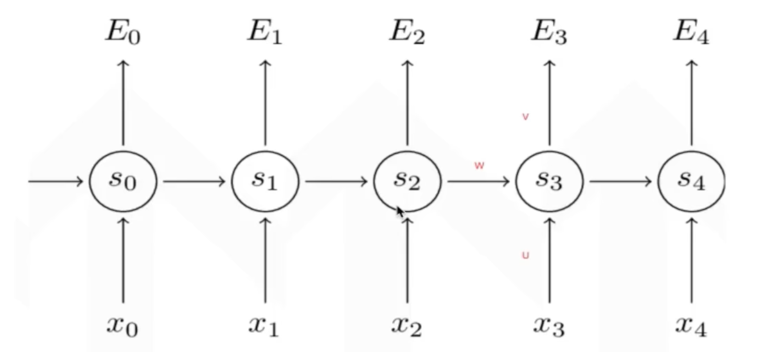

$$
s_t = tanh(U * x_t + W * s_{t-1} + b_a)
$$
$$
o_t = softmax(V * s_t + b_y)
$$

In [2]:
def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum(axis=0)

def rnn_cell_forward(x_t,s_prev,parameters):
    """
    单个cell的前向传播
    :param x_t: 当前t时刻的序列输入
    :param s_prev: 上一个cell的隐层状态输入
    :param parameters: cell中的参数
    :return: 隐层输出 s_next, out_pred
    """

    # 取出参数
    U = parameters["U"]
    W = parameters["W"]
    V = parameters["V"]
    ba = parameters["ba"]
    by = parameters["by"]

    # 根据公式计算
    # 隐层的输出计算
    s_next = np.tanh(np.dot(U,x_t) + np.dot(W, s_prev) + ba)

    # 计算cell的输出
    out_pred = softmax(np.dot(V,s_next) + by)

    # 记录每一层的值，用于反向传播
    cache = (s_next, s_prev, x_t, parameters)

    return s_next,out_pred,cache

测试 m=3是单词的个数，n=5为自定义的数字

In [3]:
np.random.seed(1)

x_t = np.random.rand(3,1)       # 当前序列的输入，因为是只有3个词，所以维度是3
s_prev = np.random.rand(5,1)    # 前一个隐层s传过来的值，U定义为5*3，自定义的数为5，所以这里是5*1

U = np.random.rand(5,3)
W = np.random.rand(5,5)         # s过来的是一个5*1的，所以W是5*5

V = np.random.rand(3,5)         # 隐层的数值乘以V之后输出，当作loss，所以应该和y的维度一样，应该是3*5，这样乘以5*1的s之后才能变成3*1
ba = np.random.rand(5,1)        # x那里过来的，U * x_t
by = np.random.rand(3,1)        # 一起经过tanh之后到上面loss，V * s_t

parameters = {"U":U,"W":W,"V":V,"ba":ba,"by":by}

s_next, out_pred, cache = rnn_cell_forward(x_t,s_prev,parameters)
print("s_next:",s_next)
print("s_next.shape",s_next.shape)
print("out_pred:",out_pred)
print("out_pred.shape",out_pred.shape)


s_next: [[0.88911409]
 [0.79387346]
 [0.94004845]
 [0.89392268]
 [0.97115073]]
s_next.shape (5, 1)
out_pred: [[0.22243827]
 [0.17932275]
 [0.59823898]]
out_pred.shape (3, 1)


In [ ]:
%%sql
